In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")
sns.set_theme()

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_cleaned.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_cleaned.csv")

category = pd.read_csv("../data/processed/category_inflows_cleaned.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_cleaned.csv")

holdings = pd.read_csv("../data/processed/portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


Task 1: NAV Trend Analysis

Prepare NAV Data

In [4]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Holdings:", holdings.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV History: (45962, 3)
Transactions: (32778, 13)
Performance: (40, 19)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Holdings: (322, 8)
Benchmark: (8050, 3)


In [5]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_plot = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())

   amfi_code       date       nav                                scheme_name
0     100016 2022-01-02  512.1124  HDFC Top 100 Fund - Regular Plan - Growth
1     100016 2022-01-03  503.1674  HDFC Top 100 Fund - Regular Plan - Growth
2     100016 2022-01-04  531.2850  HDFC Top 100 Fund - Regular Plan - Growth
3     100016 2022-01-06  474.1732  HDFC Top 100 Fund - Regular Plan - Growth
4     100016 2022-01-07  452.5840  HDFC Top 100 Fund - Regular Plan - Growth


In [6]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme Name"
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    opacity=0.2
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    opacity=0.2
)
fig.show()

In [7]:
fig.write_html("../reports/nav_trend.html")

print("NAV Trend Chart Saved Successfully")

NAV Trend Chart Saved Successfully


### Insight 1

Most mutual fund schemes show a positive long-term NAV trend between 2022 and 2026, indicating overall market growth despite short-term fluctuations.

In [8]:
print(aum.columns)

print("\n")

print(aum.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


## Task 2: AUM Growth Analysis

### AUM Growth by Fund House (2022–2025)

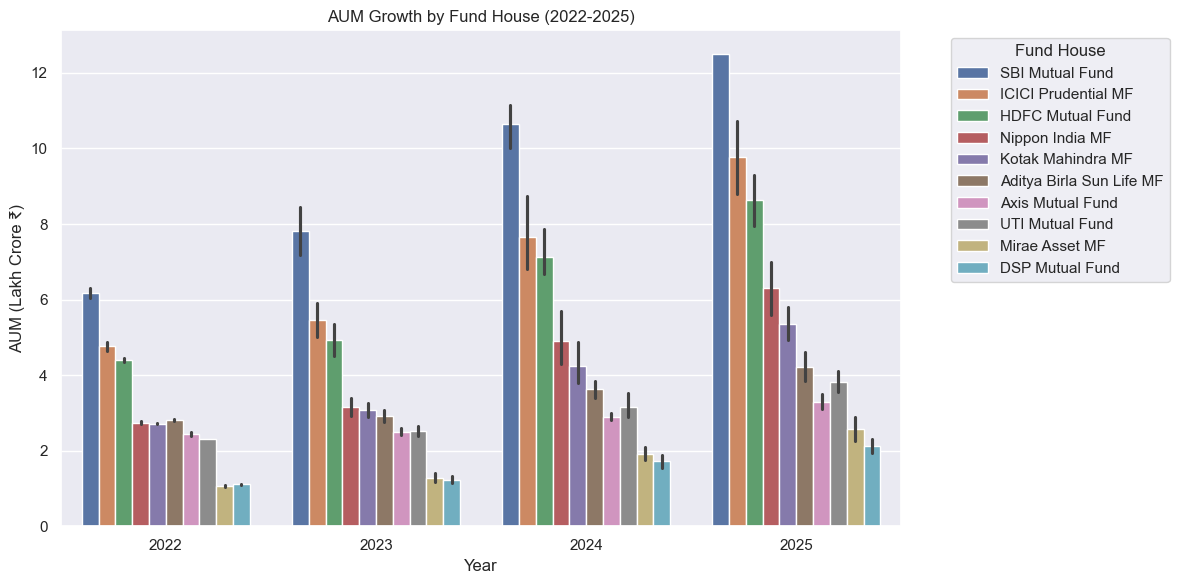

In [25]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()

# Save chart
plt.savefig("../reports/aum_growth.png", dpi=300, bbox_inches="tight")

plt.show()

## Insight 2

SBI Mutual Fund maintained the highest Assets Under Management (AUM) throughout 2022–2025, reaching approximately ₹12.5 lakh crore in 2025 and demonstrating strong market leadership.

**Chart Reference:** AUM Growth by Fund House (2022–2025)

# Task 3: SIP Inflow Time-Series (2022–2025)

In [8]:
sip["month"] = pd.to_datetime(sip["month"])

import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

# Highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x="2025-12",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True
)

fig.show()

In [9]:
fig.write_html("../reports/sip_inflow_trend.html")

print("SIP Trend Chart Saved")

SIP Trend Chart Saved


## Insight 3

SIP inflows increased steadily from 2022 to 2025, indicating growing retail investor participation in mutual funds. The highest monthly SIP inflow was recorded in December 2025 at approximately ₹31,002 crore.

**Chart Reference:** Monthly SIP Inflow Trend (2022–2025)

## Task 4: Category Inflow Heatmap

This analysis shows category-wise monthly net inflows across different mutual fund categories. Higher color intensity represents stronger investor inflows.

In [23]:
print(category.columns)

print("\n")

print(category.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


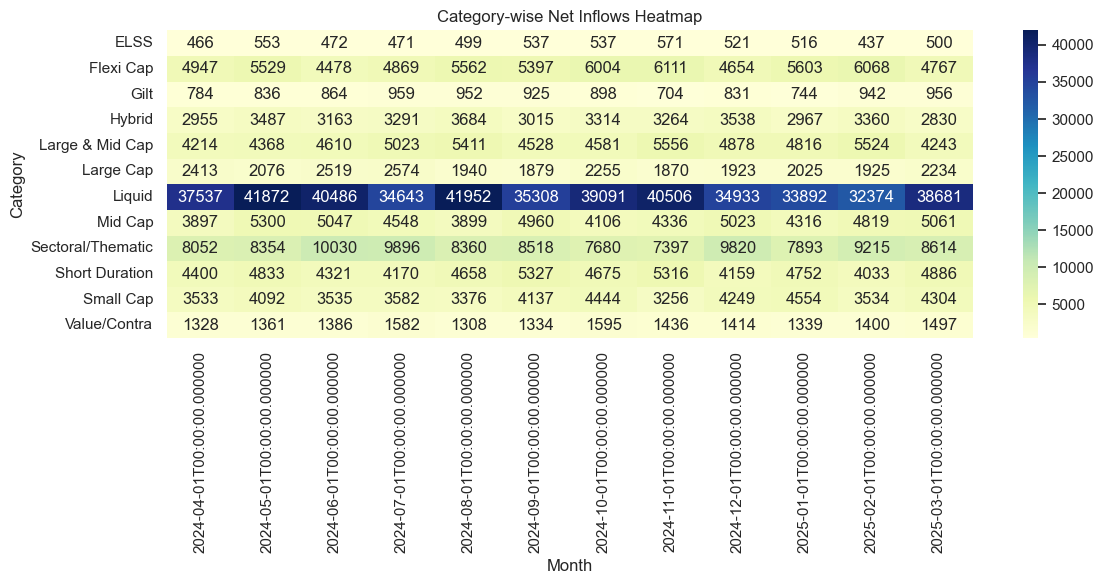

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert month column
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig("../reports/category_heatmap.png", dpi=300)

plt.show()

### Insight 4

Flexi Cap, Mid Cap, and Large & Mid Cap categories consistently received higher net inflows than other categories, indicating strong investor preference for diversified equity-oriented mutual funds.

**Chart Reference:** Category-wise Net Inflow Heatmap

## Task 5.1: Age Group Distribution

This chart shows the distribution of investors across different age groups.

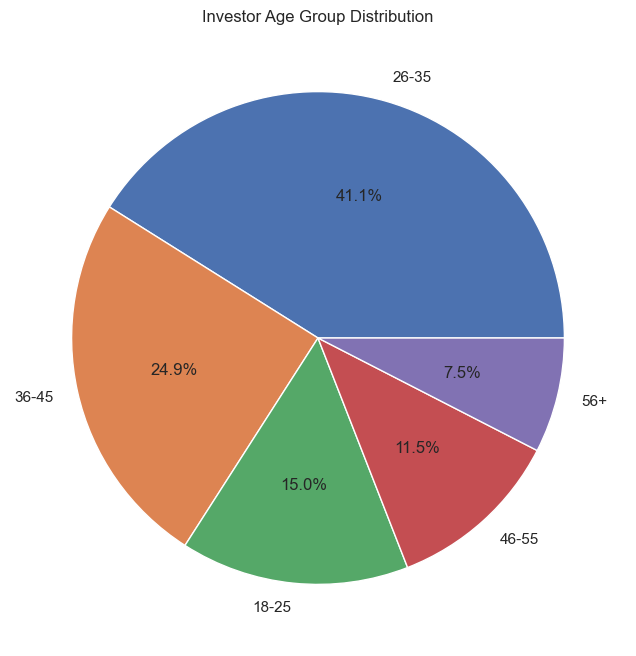

In [27]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/age_group_distribution.png", dpi=300)

plt.show()

## Task 5.2: SIP Amount Distribution by Age Group

This chart compares investment amounts across different age groups.

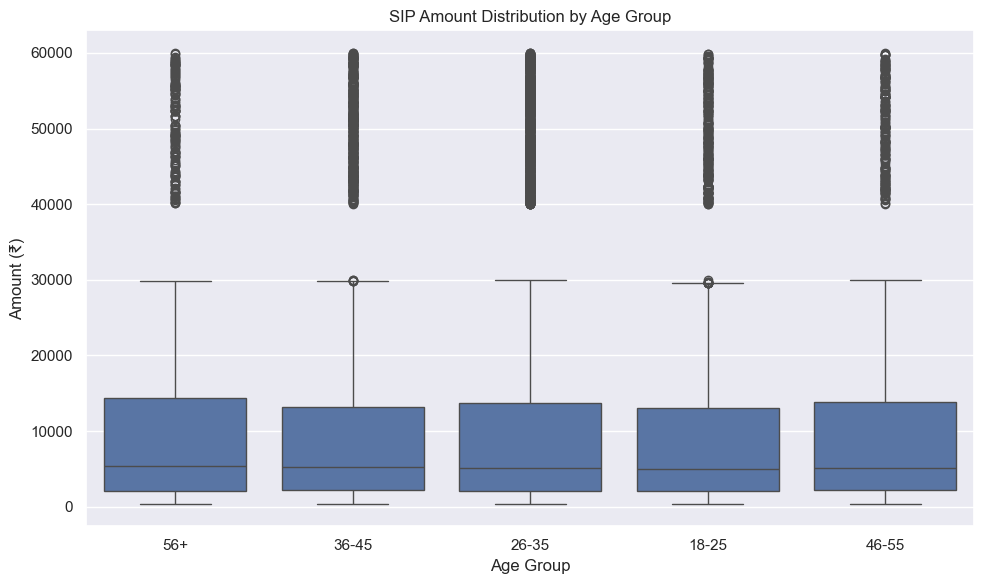

In [28]:
sip_only = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_only,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (₹)")

plt.tight_layout()

plt.savefig("../reports/sip_boxplot_agegroup.png", dpi=300)

plt.show()

## Task 5.3: Gender Distribution

This chart shows the gender-wise participation of investors.

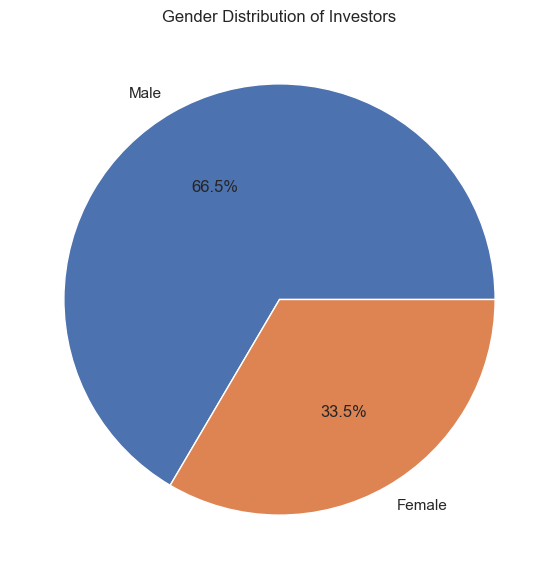

In [29]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.savefig("../reports/gender_distribution.png", dpi=300)

plt.show()

### Insight 5

The 26–45 age groups account for the largest share of mutual fund investors, indicating that working professionals form the core investor base. Gender participation appears relatively balanced, showing broad adoption across investor segments.

**Chart Reference:** Age Group Distribution, SIP Amount Distribution by Age Group, Gender Distribution

## Task 6: Geographic Distribution

This analysis examines the geographic distribution of mutual fund investments across Indian states and city tiers (T30 vs B30).

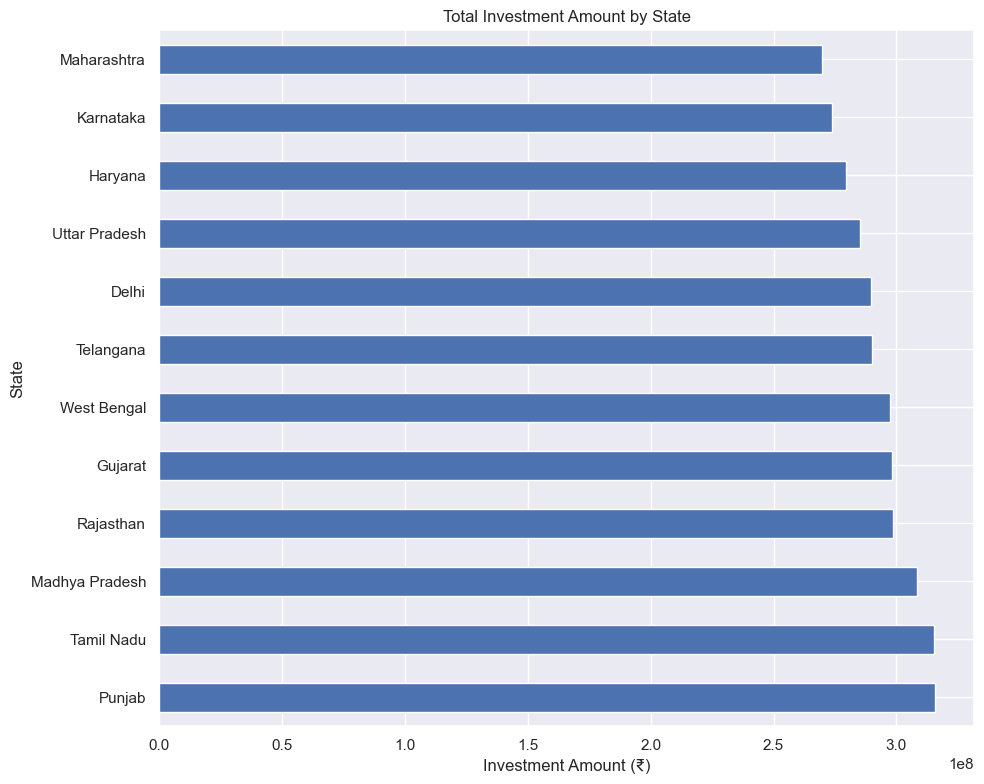

In [30]:
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

state_sip.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../reports/state_investment_distribution.png", dpi=300)

plt.show()

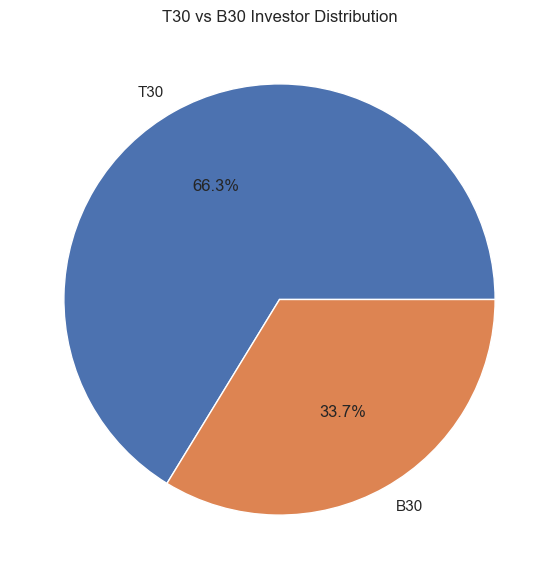

In [31]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig("../reports/city_tier_distribution.png", dpi=300)

plt.show()

### Insight 6

Major metropolitan states contribute the largest share of mutual fund investments. T30 cities account for a significant portion of investor participation, while B30 cities continue to show growing adoption, indicating expanding financial inclusion across India.

**Chart Reference:** State Investment Distribution, T30 vs B30 Investor Distribution

## Task 7: Folio Count Growth Analysis

This analysis tracks the growth of mutual fund folios from 2022 to 2025 and highlights major milestones in investor participation.

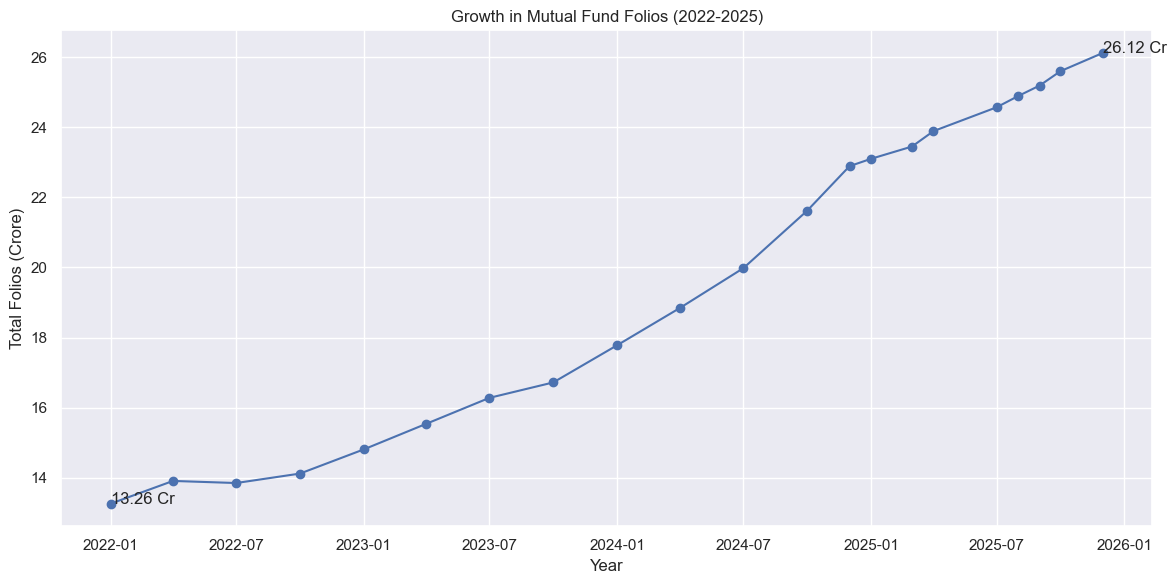

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Growth in Mutual Fund Folios (2022-2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

# Mark starting point
plt.annotate(
    "13.26 Cr",
    (folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"])
)

# Mark ending point
plt.annotate(
    "26.12 Cr",
    (folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"])
)

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/folio_growth.png", dpi=300)

plt.show()

### Insight 7

Mutual fund folio counts nearly doubled between 2022 and 2025, increasing from 13.26 crore to 26.12 crore. This reflects strong growth in retail investor participation and expanding mutual fund adoption across India.

**Chart Reference:** Growth in Mutual Fund Folios (2022–2025)

## Task 8: NAV Return Correlation Matrix

This analysis measures how closely different mutual fund schemes move together based on their daily NAV returns.

In [36]:
nav_pivot = nav_subset.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav",
    aggfunc="mean"
)

print(nav_pivot.shape)
nav_pivot.head()

(453, 10)


amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-02,512.1124,26.2096,107.8211,42.4689,53.6925,61.9412,105.2943,97.0512,561.1080,114.3590
2022-01-03,503.1674,26.5866,104.6070,41.9196,51.6126,58.9097,112.5157,88.0046,545.2016,106.8023
2022-01-04,531.2850,26.7939,96.4571,42.5286,50.5972,58.6039,106.6461,93.2224,562.8244,101.9176
2022-01-06,474.1732,27.3702,95.1712,43.0597,51.9021,62.8155,96.9902,103.6699,628.3310,105.0318
2022-01-07,452.5840,27.5292,106.9222,43.9302,53.5518,64.6487,104.3958,101.9281,664.4796,102.0542


In [37]:
returns = nav_pivot.pct_change()

corr_matrix = returns.corr()

print(corr_matrix.shape)

(10, 10)


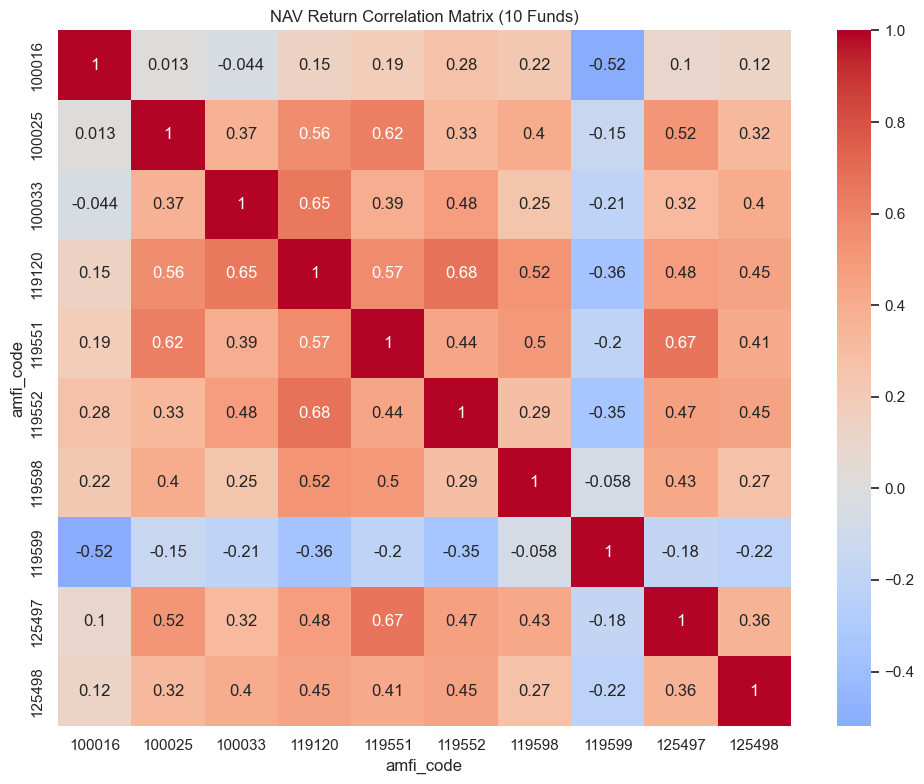

In [38]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix (10 Funds)")

plt.tight_layout()

plt.savefig("../reports/nav_correlation_matrix.png", dpi=300)

plt.show()

### Data Quality Observation

NAV history contained 6,944 duplicate (date, amfi_code) records. During EDA, duplicate entries were aggregated using mean NAV values to ensure accurate correlation analysis.

### Insight 8

Most mutual fund schemes show positive return correlations, indicating that overall market movements significantly influence fund performance. Lower-correlated funds may provide diversification benefits to investors.

**Chart Reference:** NAV Return Correlation Matrix

## Task 9: Sector Allocation Donut Chart

This analysis shows the aggregate sector exposure across mutual fund portfolio holdings and highlights sectors receiving the highest allocation.

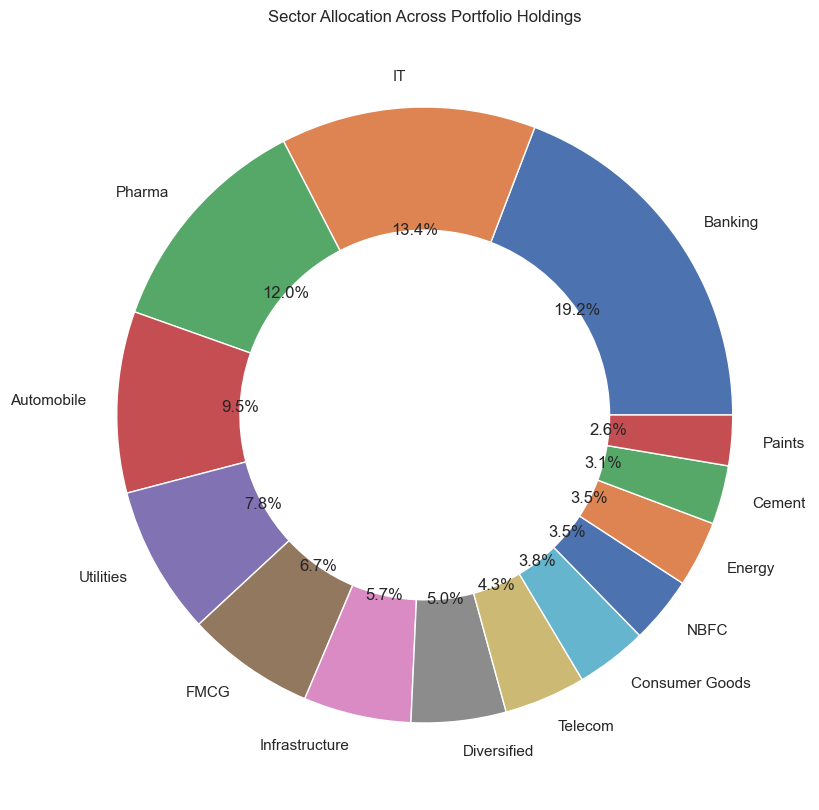

In [40]:
import matplotlib.pyplot as plt

# Aggregate sector weights
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Portfolio Holdings")

plt.savefig("../reports/sector_allocation.png", dpi=300)

plt.show()

### Insight 9

Banking, Technology, Pharma, and diversified sectors account for a significant share of mutual fund portfolio allocations. This indicates a strong preference for sectors with long-term growth potential and market leadership.

**Chart Reference:** Sector Allocation Donut Chart

## Additional Visualizations

The following charts provide supplementary insights and help meet the visualization deliverable requirements.

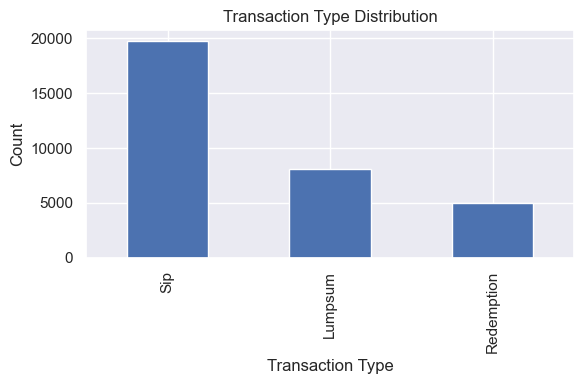

In [10]:
plt.figure(figsize=(6,4))

transactions["transaction_type"].value_counts().plot(kind="bar")

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/transaction_type_distribution.png", dpi=300)

plt.show()

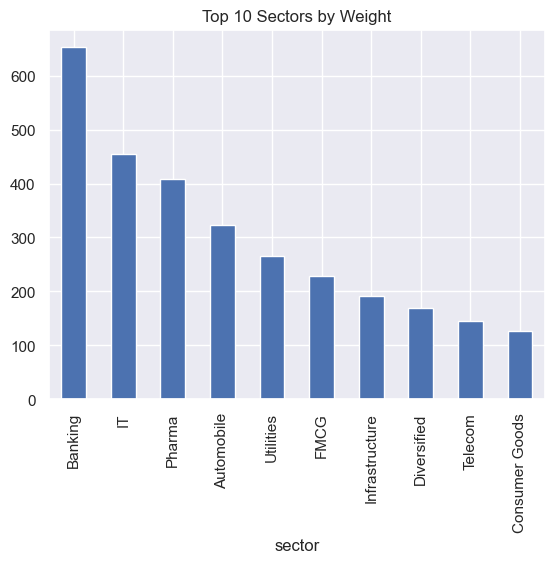

In [12]:
top_sectors = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sectors.plot(kind="bar")
plt.title("Top 10 Sectors by Weight")
plt.savefig("../reports/top10_sectors.png")
plt.show()

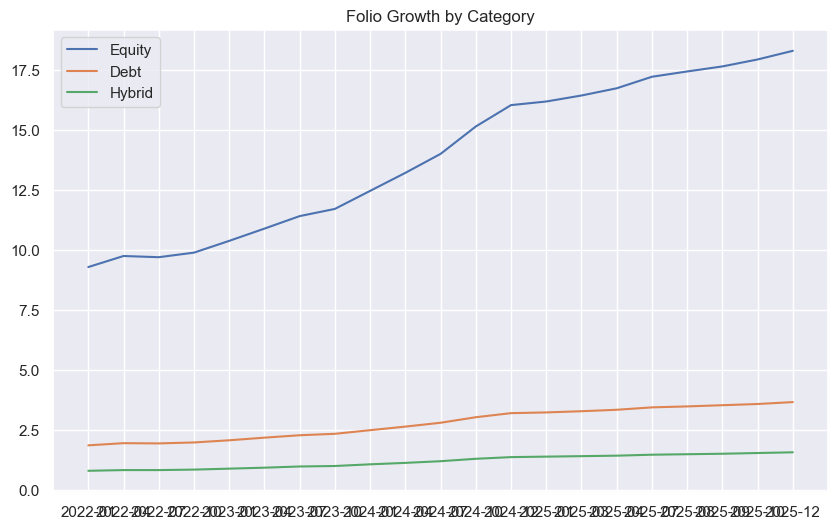

In [11]:
plt.figure(figsize=(10,6))

plt.plot(folio["month"], folio["equity_folios_crore"], label="Equity")
plt.plot(folio["month"], folio["debt_folios_crore"], label="Debt")
plt.plot(folio["month"], folio["hybrid_folios_crore"], label="Hybrid")

plt.legend()
plt.title("Folio Growth by Category")

plt.savefig("../reports/folio_category_growth.png")

plt.show()

### Insight 10

Across all analyses, mutual fund participation, SIP inflows, AUM growth, and folio counts showed a consistent upward trend between 2022 and 2025. The data indicates increasing retail investor confidence and sustained growth in the Indian mutual fund industry.

**Chart Reference:** Overall EDA Summary